In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#loading the dataset
df = pd.read_csv('loan_approval_data.csv')

In [4]:
df.head(10)
df.info()
df.isnull().sum()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## **Handling Missing Values**

In [5]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include =['number']).columns

categorical_cols
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [6]:
#sklearn imputer

from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy ='mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy = 'most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])


In [7]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## **EDA**

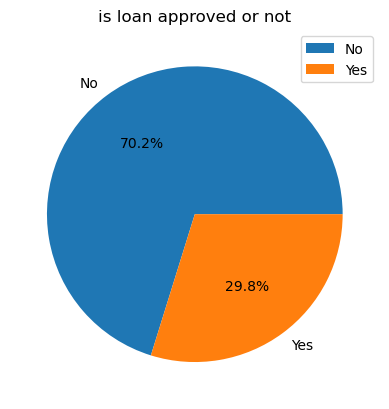

In [8]:
classes_count = df['Loan_Approved'].value_counts()
classes_count


plt.pie(classes_count, labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('is loan approved or not')
plt.legend()
plt.show()


[Text(0, 0, '621'), Text(0, 0, '379')]

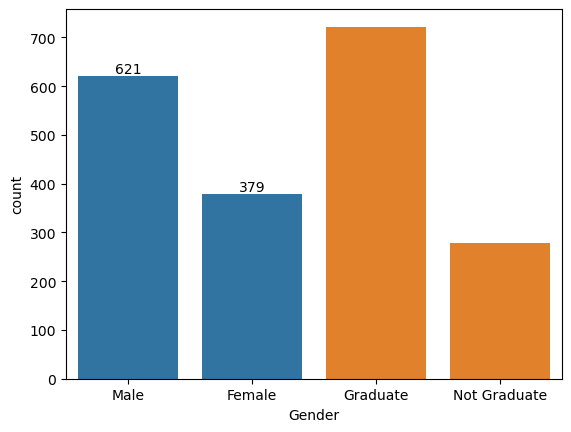

In [9]:
# analyze categories
gender_counts = df['Gender'].value_counts()
education_counts = df['Education_Level'].value_counts()
gender_counts
ax = sns.barplot(gender_counts)
ax = sns.barplot(education_counts)
ax.bar_label(ax.containers[0])

        

<Axes: xlabel='Applicant_Income', ylabel='Count'>

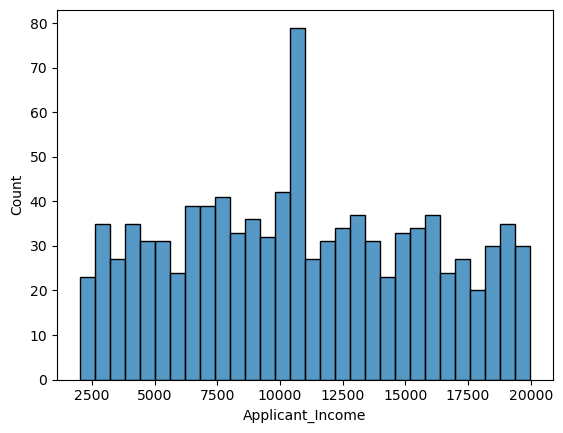

In [10]:
# analyze  income

sns.histplot(x = 'Applicant_Income',bins=30, data = df)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

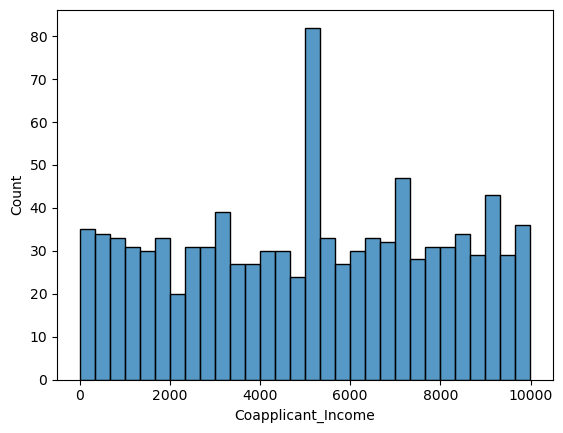

In [11]:
sns.histplot(x = 'Coapplicant_Income',bins=30, data = df)   

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

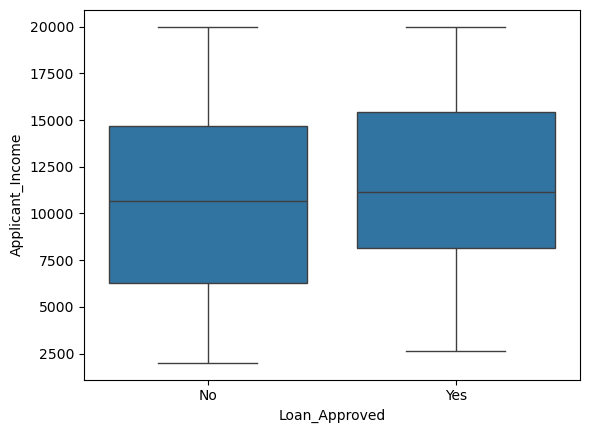

In [12]:
# outliers - boxplot
sns.boxplot(x='Loan_Approved', y='Applicant_Income', data = df)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

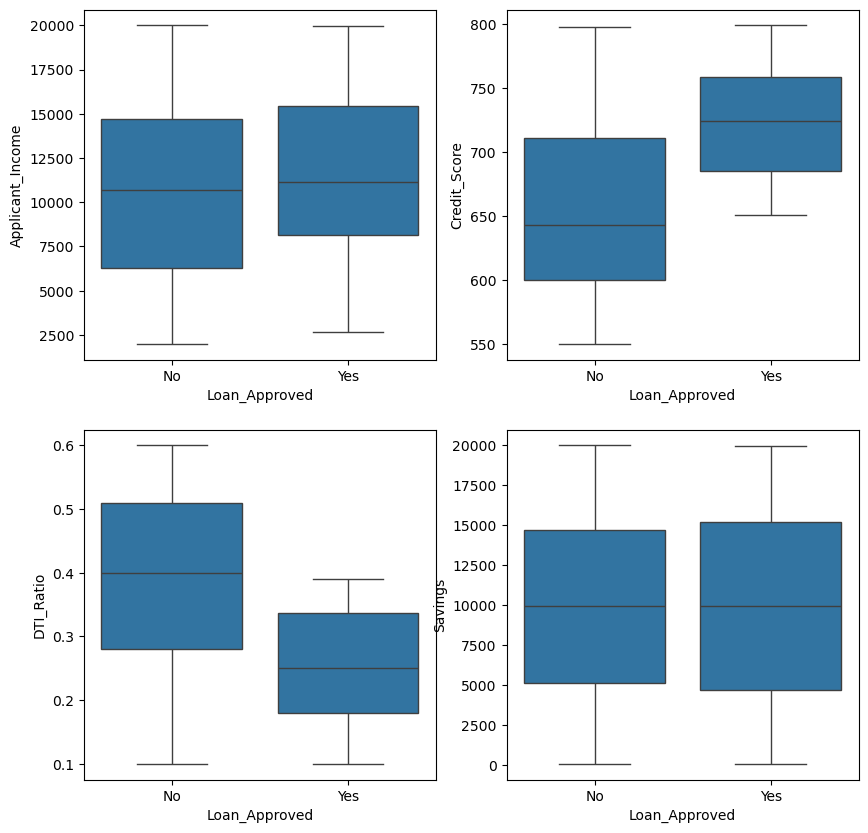

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
# outliers - boxplot
sns.boxplot(ax = axes[0,0],x='Loan_Approved', y='Applicant_Income', data = df)
sns.boxplot(ax = axes[0,1],x='Loan_Approved', y='Credit_Score', data = df)
sns.boxplot(ax = axes[1,0],x='Loan_Approved', y='DTI_Ratio', data = df)
sns.boxplot(ax = axes[1,1],x='Loan_Approved', y='Savings', data = df)

<Axes: xlabel='Credit_Score', ylabel='Count'>

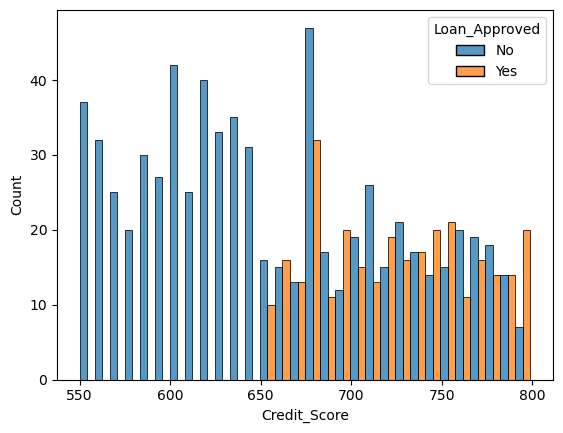

In [14]:
# credit score vs loan approval
sns.histplot(x = 'Credit_Score', bins=30, data = df, hue = 'Loan_Approved', multiple='dodge')

In [15]:
# rempve applicant id 
df = df.drop('Applicant_ID' , axis =1)

In [16]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


<Axes: xlabel='Employer_Category', ylabel='count'>

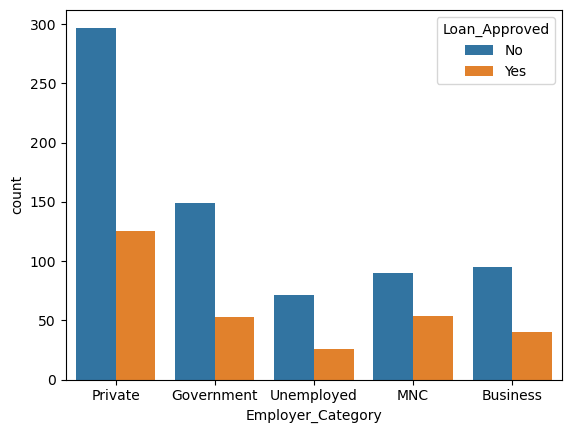

In [17]:
sns.countplot(x='Employer_Category', hue='Loan_Approved', data=df)

<Axes: xlabel='Loan_Approved', ylabel='count'>

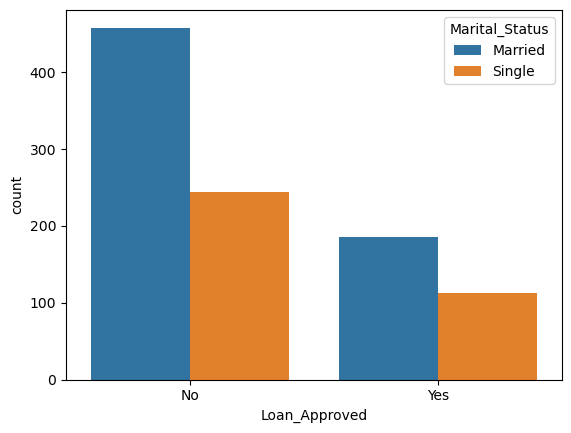

In [18]:
sns.countplot(x = 'Loan_Approved', hue = 'Marital_Status', data = df)

<Axes: xlabel='Gender', ylabel='count'>

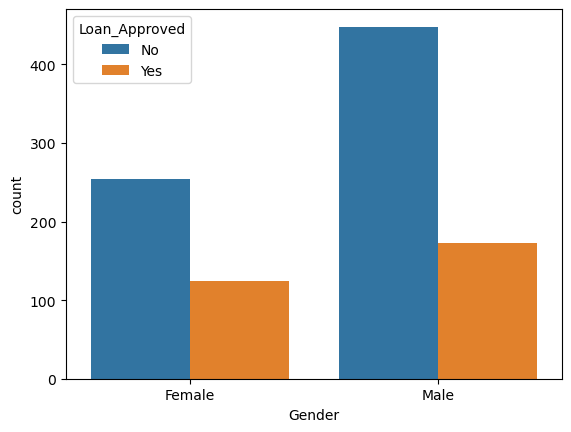

In [19]:
sns.countplot(x = 'Gender', hue = 'Loan_Approved', data = df)

In [20]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## Feature Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])
df['Education_Level'] = le.fit_transform(df['Education_Level']) 



In [22]:
from sklearn.preprocessing import OneHotEncoder

cols = ['Employment_Status', 'Marital_Status', 'Employer_Category', 'Property_Area', 'Gender', 'Loan_Purpose']


ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

# Drop AFTER encoding
df = df.drop(columns=cols)

# Add encoded columns
df = pd.concat([df, encoded_df], axis=1)


In [23]:
encoded_df.head()   

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [24]:
df.head()   
df.describe()
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

## correlation heatmap ##

<Axes: >

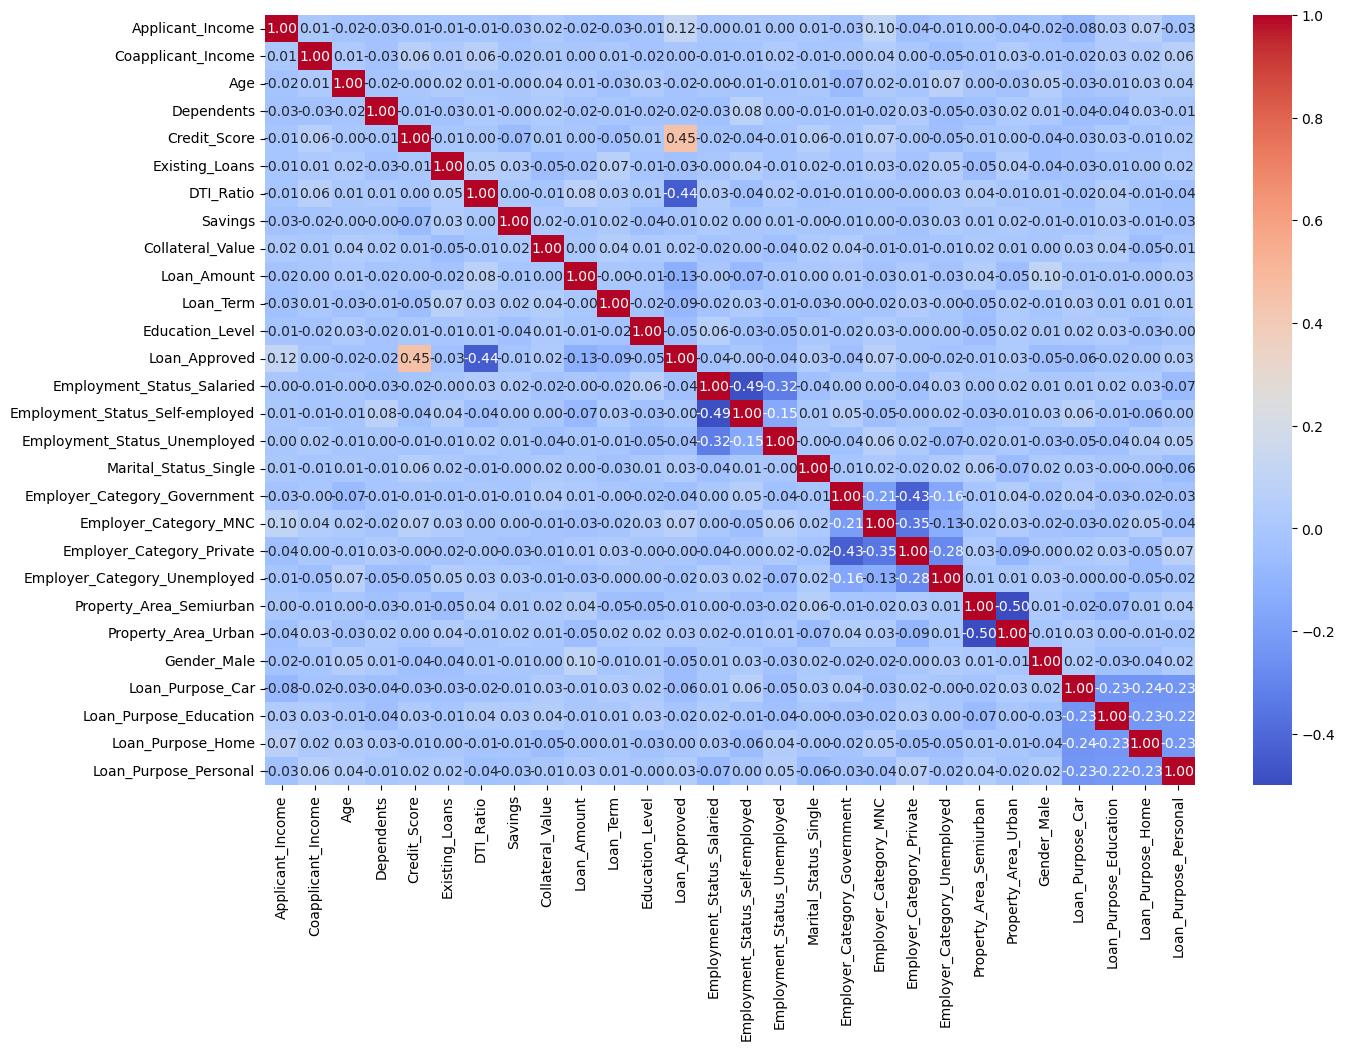

In [32]:
nums_col = df.select_dtypes(include=['number']).columns
corr_matrix = df[nums_col].corr()
corr_matrix['Loan_Approved'].sort_values(ascending=False)

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm' , fmt='.2f' )

## train-test-split + feature scaling 

In [33]:
X = df.drop('Loan_Approved', axis=1)    
y = df['Loan_Approved']

In [35]:
X.head()
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

In [39]:
X_train.head()
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

## train and evaluate 

In [65]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report    

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

#evaluation
print(" logistic regression")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))  
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))  
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


 logistic regression
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 Score: 0.7768595041322314
Accuracy: 0.865
Confusion Matrix:
 [[126  13]
 [ 14  47]]


In [52]:
# KNN CLASSIFIER 
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

#evaluation
print("KNN CLASSIFIER")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))  
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))  
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

KNN CLASSIFIER
Precision: 0.6086956521739131
Recall: 0.45901639344262296
F1 Score: 0.5233644859813084
Accuracy: 0.745
Confusion Matrix:
 [[121  18]
 [ 33  28]]


In [62]:
# naiyve bais
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

#evaluation
print("naive bayes")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))  
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))  
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

naive bayes
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
Accuracy: 0.865
Confusion Matrix:
 [[128  11]
 [ 16  45]]


## best model on the basis of precision is naive bayes

In [54]:
# feature engineering

In [61]:
import numpy as np 
df['DTI_Ratio_sq'] = df['DTI_Ratio'] ** 2
df['Credit_Score_sq'] = df['Credit_Score'] ** 2

# df['Applicant_Income_log'] = np.log1p(df['Applicant_Income']) # skewed data ko log transform krke normal krna

X = df.drop(columns=['Loan_Approved', 'Credit_Score', 'DTI_Ratio'])
y = df['Loan_Approved']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
